### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"..\data\customer_churn_sample (1).csv")

In [3]:
print(df.shape)

(15, 11)


In [4]:
print(df.head())

  CustomerID  Gender  Age  TenureMonths SubscriptionType  MonthlyCharges  \
0  CUST-1001  Female   34            12            Basic           49.99   
1  CUST-1002    Male   45            24              Pro           79.99   
2  CUST-1003  Female   29             6            Basic           49.99   
3  CUST-1004    Male   52            36       Enterprise          149.99   
4  CUST-1005  Female   41             8              Pro           79.99   

   TotalCharges    ContractType  SupportTickets  PaymentMethod Churn  
0        599.88  Month-to-Month               3    Credit Card   Yes  
1       1919.76        One Year               1  Bank Transfer    No  
2        299.94  Month-to-Month               5            UPI   Yes  
3       5399.64        Two Year               0    Credit Card    No  
4        639.92  Month-to-Month               4     Debit Card   Yes  


In [5]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'TenureMonths', 'SubscriptionType',
       'MonthlyCharges', 'TotalCharges', 'ContractType', 'SupportTickets',
       'PaymentMethod', 'Churn'],
      dtype='str')


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        15 non-null     str    
 1   Gender            15 non-null     str    
 2   Age               15 non-null     int64  
 3   TenureMonths      15 non-null     int64  
 4   SubscriptionType  15 non-null     str    
 5   MonthlyCharges    15 non-null     float64
 6   TotalCharges      15 non-null     float64
 7   ContractType      15 non-null     str    
 8   SupportTickets    15 non-null     int64  
 9   PaymentMethod     15 non-null     str    
 10  Churn             15 non-null     str    
dtypes: float64(2), int64(3), str(6)
memory usage: 1.4 KB
None


In [7]:
print(df.describe(include="all"))

       CustomerID  Gender        Age  TenureMonths SubscriptionType  \
count          15      15  15.000000     15.000000               15   
unique         15       2        NaN           NaN                3   
top     CUST-1001  Female        NaN           NaN            Basic   
freq            1       8        NaN           NaN                7   
mean          NaN     NaN  39.066667     18.800000              NaN   
std           NaN     NaN  11.392144     14.333776              NaN   
min           NaN     NaN  23.000000      2.000000              NaN   
25%           NaN     NaN  30.000000      7.000000              NaN   
50%           NaN     NaN  38.000000     15.000000              NaN   
75%           NaN     NaN  47.000000     27.000000              NaN   
max           NaN     NaN  60.000000     48.000000              NaN   

        MonthlyCharges  TotalCharges    ContractType  SupportTickets  \
count        15.000000     15.000000              15       15.000000   
uni

### Check Missing Values

In [8]:
print(df.isnull().sum())

CustomerID          0
Gender              0
Age                 0
TenureMonths        0
SubscriptionType    0
MonthlyCharges      0
TotalCharges        0
ContractType        0
SupportTickets      0
PaymentMethod       0
Churn               0
dtype: int64


### Check Duplicate Values

In [9]:
print(df.duplicated().sum())

0


In [10]:
# Remove Duplicates

print(df.drop_duplicates())

   CustomerID  Gender  Age  TenureMonths SubscriptionType  MonthlyCharges  \
0   CUST-1001  Female   34            12            Basic           49.99   
1   CUST-1002    Male   45            24              Pro           79.99   
2   CUST-1003  Female   29             6            Basic           49.99   
3   CUST-1004    Male   52            36       Enterprise          149.99   
4   CUST-1005  Female   41             8              Pro           79.99   
5   CUST-1006    Male   31            18            Basic           49.99   
6   CUST-1007  Female   23             3            Basic           49.99   
7   CUST-1008    Male   60            48       Enterprise          149.99   
8   CUST-1009  Female   38            15              Pro           79.99   
9   CUST-1010    Male   27             4            Basic           49.99   
10  CUST-1011  Female   49            30       Enterprise          149.99   
11  CUST-1012    Male   33            14              Pro           79.99   

### Standardize the churn column

In [11]:
df["Churn_Flag"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [12]:
print(df["Churn_Flag"].value_counts())

Churn_Flag
0    8
1    7
Name: count, dtype: int64


### Calculate Baseline Churn Rate

*Formula:*

Churn Rate = (Number of Churned Customer / Total Customers) x 100

In [13]:
total_customers = len(df)

churned_customers = df["Churn_Flag"].sum()

churn_rate = (
    churned_customers / total_customers
) * 100

print("Total Customers :", total_customers)
print("Churned Customers :", churned_customers)
print("Churned Rate :", round(churn_rate, 2), "%")

Total Customers : 15
Churned Customers : 7
Churned Rate : 46.67 %


### Calculate MRR Loss

MRR = Monthly Recurring Revenue

MRR Loss = ∑ MonthlyCharges(churned​)

In [14]:
mrr_loss = df.loc[
    df["Churn_Flag"] == 1,
    "MonthlyCharges"
].sum()

print("Monthly Recurring Revenue Loss :", round(mrr_loss, 2))

Monthly Recurring Revenue Loss : 409.93


In [15]:
# Total Current MRR Loss
total_mrr = df["MonthlyCharges"].sum()

remaining_mrr = df.loc[
    df["Churn_Flag"] == 0,
    "MonthlyCharges"
].sum()

print("Total MRR :", total_mrr)
print("MRR from retained customers :", remaining_mrr)
print("MRR lost :", mrr_loss)

Total MRR : 1269.8500000000001
MRR from retained customers : 859.9200000000001
MRR lost : 409.93


### Calculate Customer Lifetime Value(CLV)

CLV = Average Customer Revenue x Average Customer Lifetime

In [16]:
avg_monthly_revenue = df["MonthlyCharges"].mean()

avg_tenure = df["TenureMonths"].mean()

clv = avg_monthly_revenue * avg_tenure

print("Average Monthly Revenue :", round(avg_monthly_revenue, 2))

print("Average Customer Lifetime :", round(avg_tenure, 2), "months")

print("Estimated CLV :", round(clv, 2))

Average Monthly Revenue : 84.66
Average Customer Lifetime : 18.8 months
Estimated CLV : 1591.55


### Churn by ContractType

In [17]:
contract_churn = pd.crosstab(
    df["ContractType"],
    df["Churn_Flag"],
    normalize="index"
) * 100

contract_churn

Churn_Flag,0,1
ContractType,,
Month-to-Month,0.0,100.0
One Year,100.0,0.0
Two Year,100.0,0.0


In [18]:
contract_churn_rate = (
    df.groupby("ContractType")["Churn_Flag"]
    .mean() * 100
)

print(contract_churn_rate)

ContractType
Month-to-Month    100.0
One Year            0.0
Two Year            0.0
Name: Churn_Flag, dtype: float64


**Visualization**

<function matplotlib.pyplot.show(close=None, block=None)>

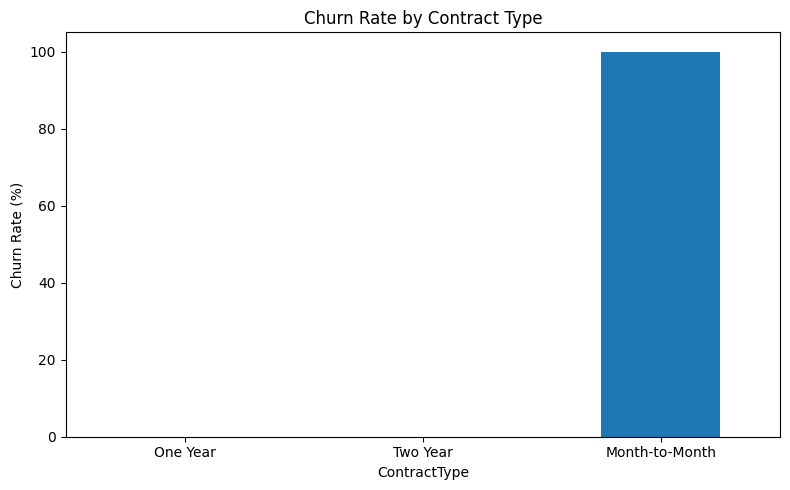

In [19]:
# Visualize

plt.figure(figsize=(8,5))

contract_churn_rate.sort_values().plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("ContractType")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show

### Churn by TenureMonths

In [20]:
tenure_months_churn = (
    df.groupby("TenureMonths", observed=True)["Churn_Flag"]
    .mean() * 100
)

print(tenure_months_churn)

TenureMonths
2     100.0
3     100.0
4     100.0
6     100.0
8     100.0
12    100.0
14    100.0
15      0.0
18      0.0
22      0.0
24      0.0
30      0.0
36      0.0
40      0.0
48      0.0
Name: Churn_Flag, dtype: float64


**Visualization**

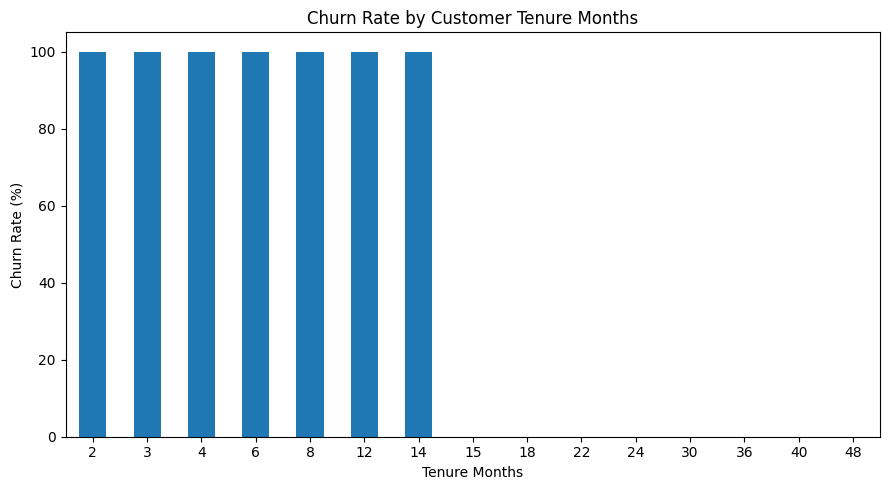

In [21]:
plt.figure(figsize=(9,5))

tenure_months_churn.plot(kind="bar")

plt.title("Churn Rate by Customer Tenure Months")
plt.xlabel("Tenure Months")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Churn by Payment Methods

In [22]:
payment_methods_churn = (
    df.groupby("PaymentMethod")["Churn_Flag"]
    .mean() * 100
)

print(payment_methods_churn)

PaymentMethod
Bank Transfer      0.000000
Credit Card       33.333333
Debit Card       100.000000
UPI               75.000000
Name: Churn_Flag, dtype: float64


**Visualization**

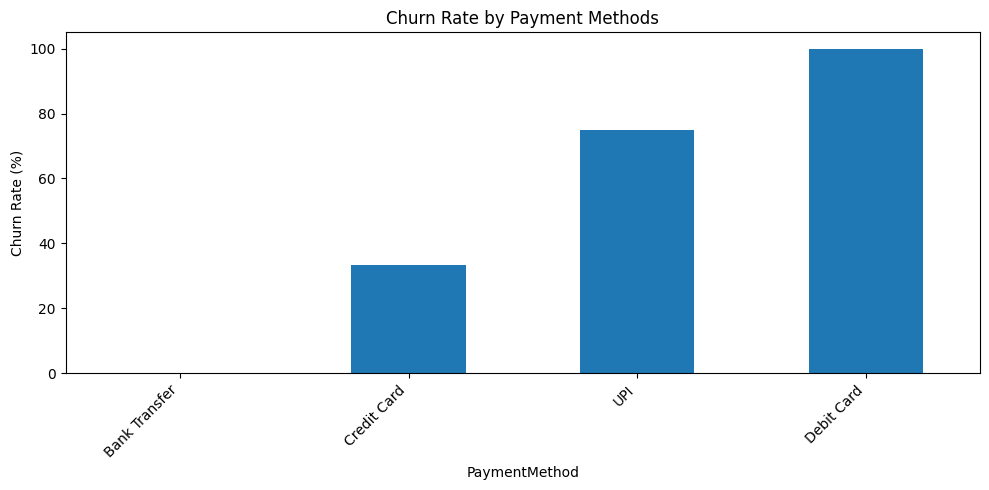

In [23]:
plt.figure(figsize=(10,5))

payment_methods_churn.sort_values().plot(kind="bar")

plt.title("Churn Rate by Payment Methods")
plt.xlabel("PaymentMethod")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


### Churn Distribution

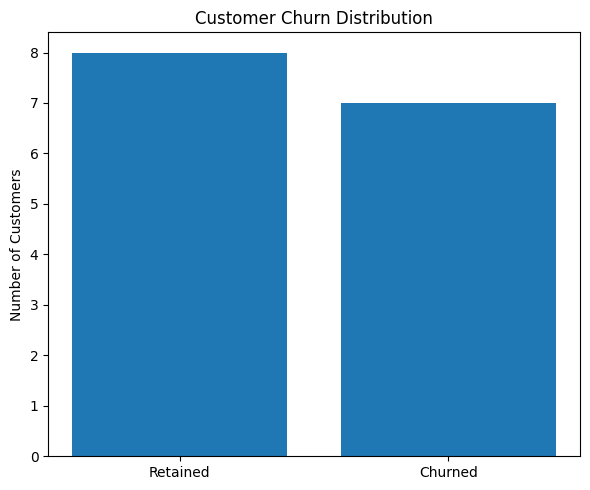

In [24]:
churn_count = df["Churn_Flag"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    ["Retained","Churned"],
    [
        churn_count.get(0,0),
        churn_count.get(1,0)
    ]
)

plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Boxplot

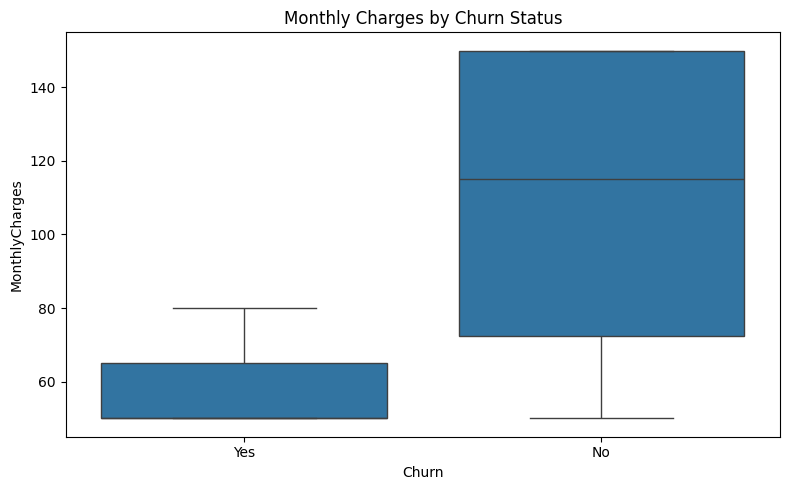

In [25]:
# A boxplot can show whether monthly charges differ between churned and retained customers.

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")

plt.tight_layout()
plt.show()

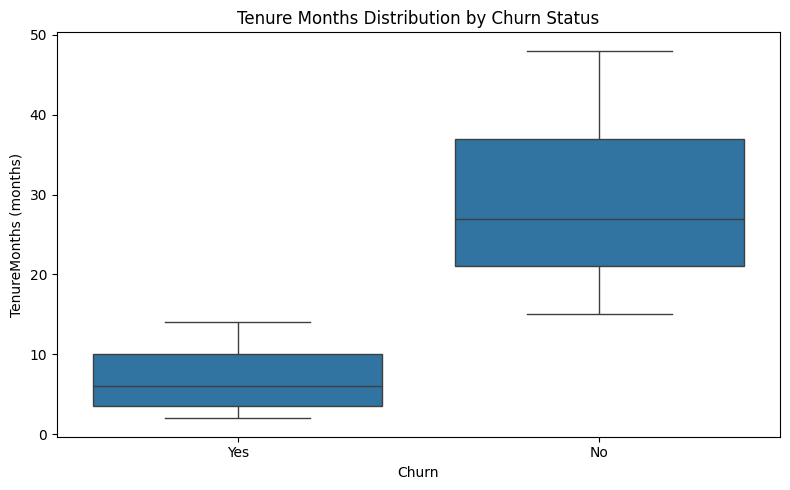

In [26]:
# For TenureMonths Distribution

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TenureMonths"
)

plt.title("Tenure Months Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("TenureMonths (months)")

plt.tight_layout()
plt.show()

### Correlation Heatmap

In [27]:
numeric_cols = df.select_dtypes(
    include=["int64","float64"]
)

corr = numeric_cols.corr()

**Visualization**

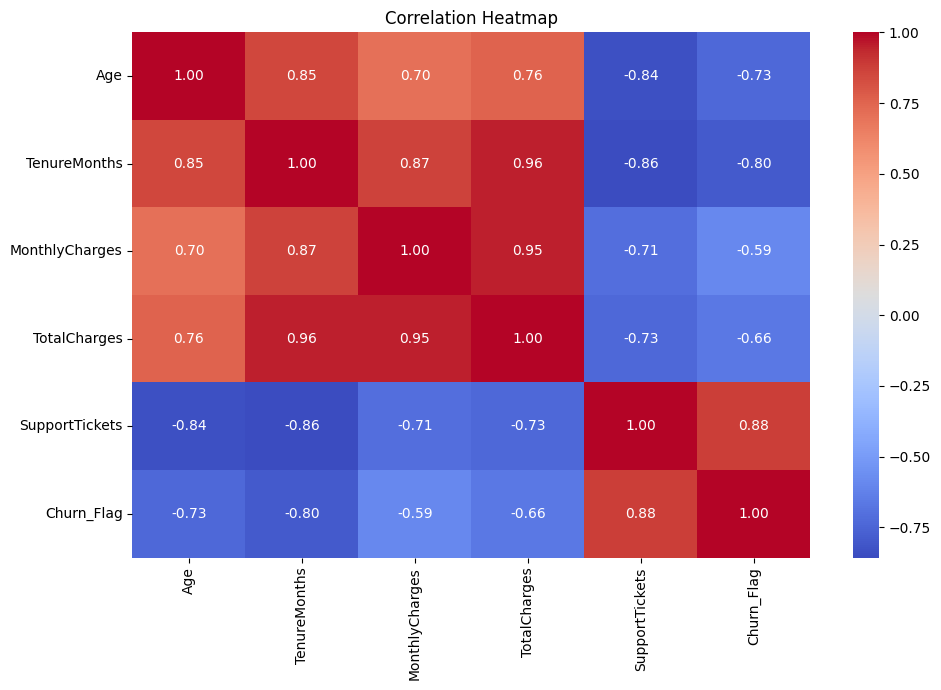

In [28]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Find Behavioral Drivers

*BEHAVIORAL DRIVERS* — using columns that exist in THIS dataset.

In [29]:
def churn_by_category(column):
    """ Shows Churn rate % for each value in a column, highest first."""
    return(
        df.groupby(column)["Churn_Flag"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .round(2)
    )

*Run it on real columns*

In [30]:
# Churn by Contract Type
print("Churn by Contract Type :")
print(churn_by_category("ContractType"))

# Churn by Payment Methods
print("\nChurn by Payment Methods :")
print(churn_by_category("PaymentMethod"))

# Churn by Subscription Type
print("\nChurn by Subscription Type :")
print(churn_by_category("SubscriptionType"))

# Gender
print("\nGender :")
print(churn_by_category("Gender"))

# Churn by Support Tickets
print("\nChurn by Support Tickets :")
print(churn_by_category("SupportTickets"))

Churn by Contract Type :
ContractType
Month-to-Month    100.0
One Year            0.0
Two Year            0.0
Name: Churn_Flag, dtype: float64

Churn by Payment Methods :
PaymentMethod
Debit Card       100.00
UPI               75.00
Credit Card       33.33
Bank Transfer      0.00
Name: Churn_Flag, dtype: float64

Churn by Subscription Type :
SubscriptionType
Basic         71.43
Pro           50.00
Enterprise     0.00
Name: Churn_Flag, dtype: float64

Gender :
Gender
Female    50.00
Male      42.86
Name: Churn_Flag, dtype: float64

Churn by Support Tickets :
SupportTickets
5    100.0
4    100.0
3    100.0
6    100.0
2      0.0
0      0.0
1      0.0
Name: Churn_Flag, dtype: float64


*Numeric drivers* — compare averages instead of categories

In [31]:
# Avg Monthly Charges by Churn
print("Avg Monthly Charges by Churn :")
print(df.groupby("Churn")["MonthlyCharges"].mean().round(2), "\n")

# Avg Tenure (months) by Churn
print("Avg Tenure (months) by Churn :")
print(df.groupby("Churn")["TenureMonths"].mean().round(2), "\n")

# Avg Age by Churn
print("Avg Age by Churn :")
print(df.groupby("Churn")["Age"].mean().round(2))

Avg Monthly Charges by Churn :
Churn
No     107.49
Yes     58.56
Name: MonthlyCharges, dtype: float64 

Avg Tenure (months) by Churn :
Churn
No     29.12
Yes     7.00
Name: TenureMonths, dtype: float64 

Avg Age by Churn :
Churn
No     46.62
Yes    30.43
Name: Age, dtype: float64


### The Driver Summary Table

In [32]:
driver_summary = pd.DataFrame({
    "Churn Rate (%)": [
        churn_by_category("ContractType").max(),
        churn_by_category("PaymentMethod").max(),
        churn_by_category("SubscriptionType").max(),
        churn_by_category("SupportTickets").max(),
    ],
    "Worst Group": [
        churn_by_category("ContractType").idxmax(),
        churn_by_category("PaymentMethod").idxmax(),
        churn_by_category("SubscriptionType").idxmax(),
        churn_by_category("SupportTickets").idxmax(),
    ]
}, index=["ContractType", "PaymentMethod", "SubscriptionType", "SupportTickets"])

print(driver_summary.sort_values("Churn Rate (%)", ascending=False))

                  Churn Rate (%)     Worst Group
ContractType              100.00  Month-to-Month
PaymentMethod             100.00      Debit Card
SupportTickets            100.00               5
SubscriptionType           71.43           Basic
